# Pairwise Scatter Plots (Journal Style)

Three pairwise parameter scatter plots, each in its own figure and its own code cell, using the agreed journal-style defaults.


In [36]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl


In [37]:
repo_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
ensemble_csv = repo_root / 'two_components/outputs/phase_exploration/exploration_ensemble.csv'
if not ensemble_csv.exists():
    ensemble_csv = repo_root / 'two_components_/outputs/phase_exploration/exploration_ensemble.csv'

ensemble = pd.read_csv(ensemble_csv)
ensemble.head()


,run_idx,seed,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,J_m,R2
0,1,101,11.499208,48.875504,14.306458,2.316610,0.295805,0.631880,0.032658,0.998593
1,2,102,11.594517,48.033103,14.372158,2.499534,0.309429,0.603831,0.034102,0.998558
2,3,103,11.543427,46.876277,14.969934,2.432204,0.290120,0.624254,0.033832,0.998523
3,4,104,11.578372,48.419834,14.336083,2.477860,0.303948,0.625736,0.032566,0.998633
4,5,105,11.693850,48.764312,13.486999,2.749373,0.333392,0.584234,0.034437,0.998449


## Global aesthetics

Run once so all figures in this notebook share the same journal-style defaults.


In [38]:
_pt = 1.0
_pt_hair = 0.5
font_size = 11
_grid_gray = '#F2F2F2'

JOURNAL_RC = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'text.color': 'black',
    'axes.labelcolor': 'black',
    'axes.edgecolor': 'black',
    'xtick.color': 'black',
    'ytick.color': 'black',
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'pdf.fonttype': 42,
}

plt.rcParams.update(JOURNAL_RC)

# Match histogram convention: color by NRMSE (%) with fixed range.
ensemble['NRMSE_pct'] = ensemble['J_m'] * 100.0
nrmse_norm = mpl.colors.Normalize(vmin=3.0, vmax=3.7)


## MRT1 vs MRT2
Scatter of `best_MRT1` vs `best_MRT2` colored by objective value `J_m`.


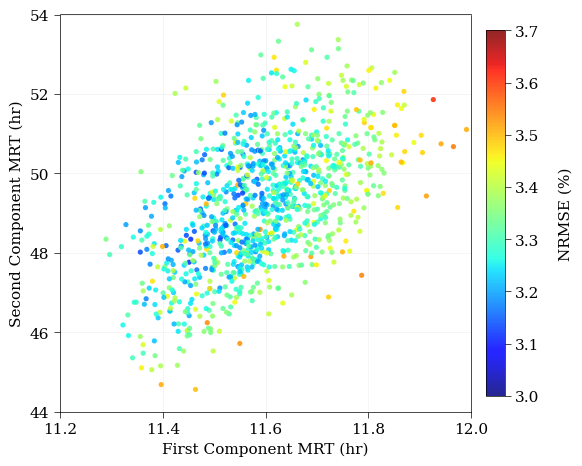

In [39]:
cx = "best_MRT1"
cy = "best_MRT2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

sc = ax.scatter(
    ensemble[cx],
    ensemble[cy],
    c=ensemble["NRMSE_pct"],
    cmap="jet",
    norm=nrmse_norm,
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component MRT (hr)")
ax.set_ylabel("Second Component MRT (hr)")
ax.set_xlim([11.2, 12.0])
ax.set_ylim([44, 54])

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.92, pad=0.03)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_mrt1_mrt2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()



## Pe1 vs Pe2


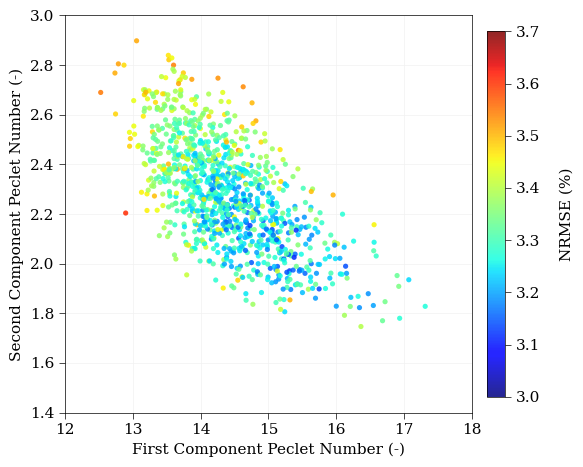

In [40]:
cx = "best_Pe1"
cy = "best_Pe2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

sc = ax.scatter(
    ensemble[cx],
    ensemble[cy],
    c=ensemble["NRMSE_pct"],
    cmap="jet",
    norm=nrmse_norm,
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component Peclet Number (-)")
ax.set_ylabel("Second Component Peclet Number (-)")
ax.set_xlim([12, 18])
ax.set_ylim([1.4, 3])

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.92, pad=0.03)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_pe1_pe2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()


## fr1 vs fr2


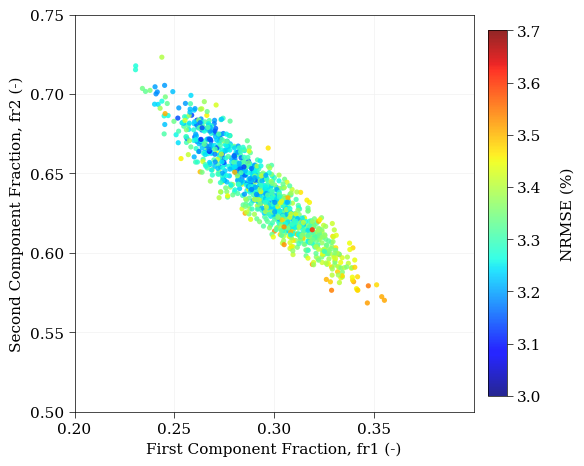

In [ ]:
cx = "best_fr1"
cy = "best_fr2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

sc = ax.scatter(
    ensemble[cx],
    ensemble[cy],
    c=ensemble["NRMSE_pct"],
    cmap="jet",
    norm=nrmse_norm,
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component Fraction, fr1 (-)")
ax.set_ylabel("Second Component Fraction, fr2 (-)")
ax.set_xlim([0.2, 0.4])
ax.set_xticks(np.arange(0.2, 0.40, 0.05))
ax.set_ylim([0.5, 0.75])

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.92, pad=0.03)
cbar.set_label("NRMSE (%)", labelpad=14)
cbar.ax.tick_params(width=_pt_hair, length=4)
cbar.outline.set_linewidth(_pt_hair)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_fr1_fr2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()


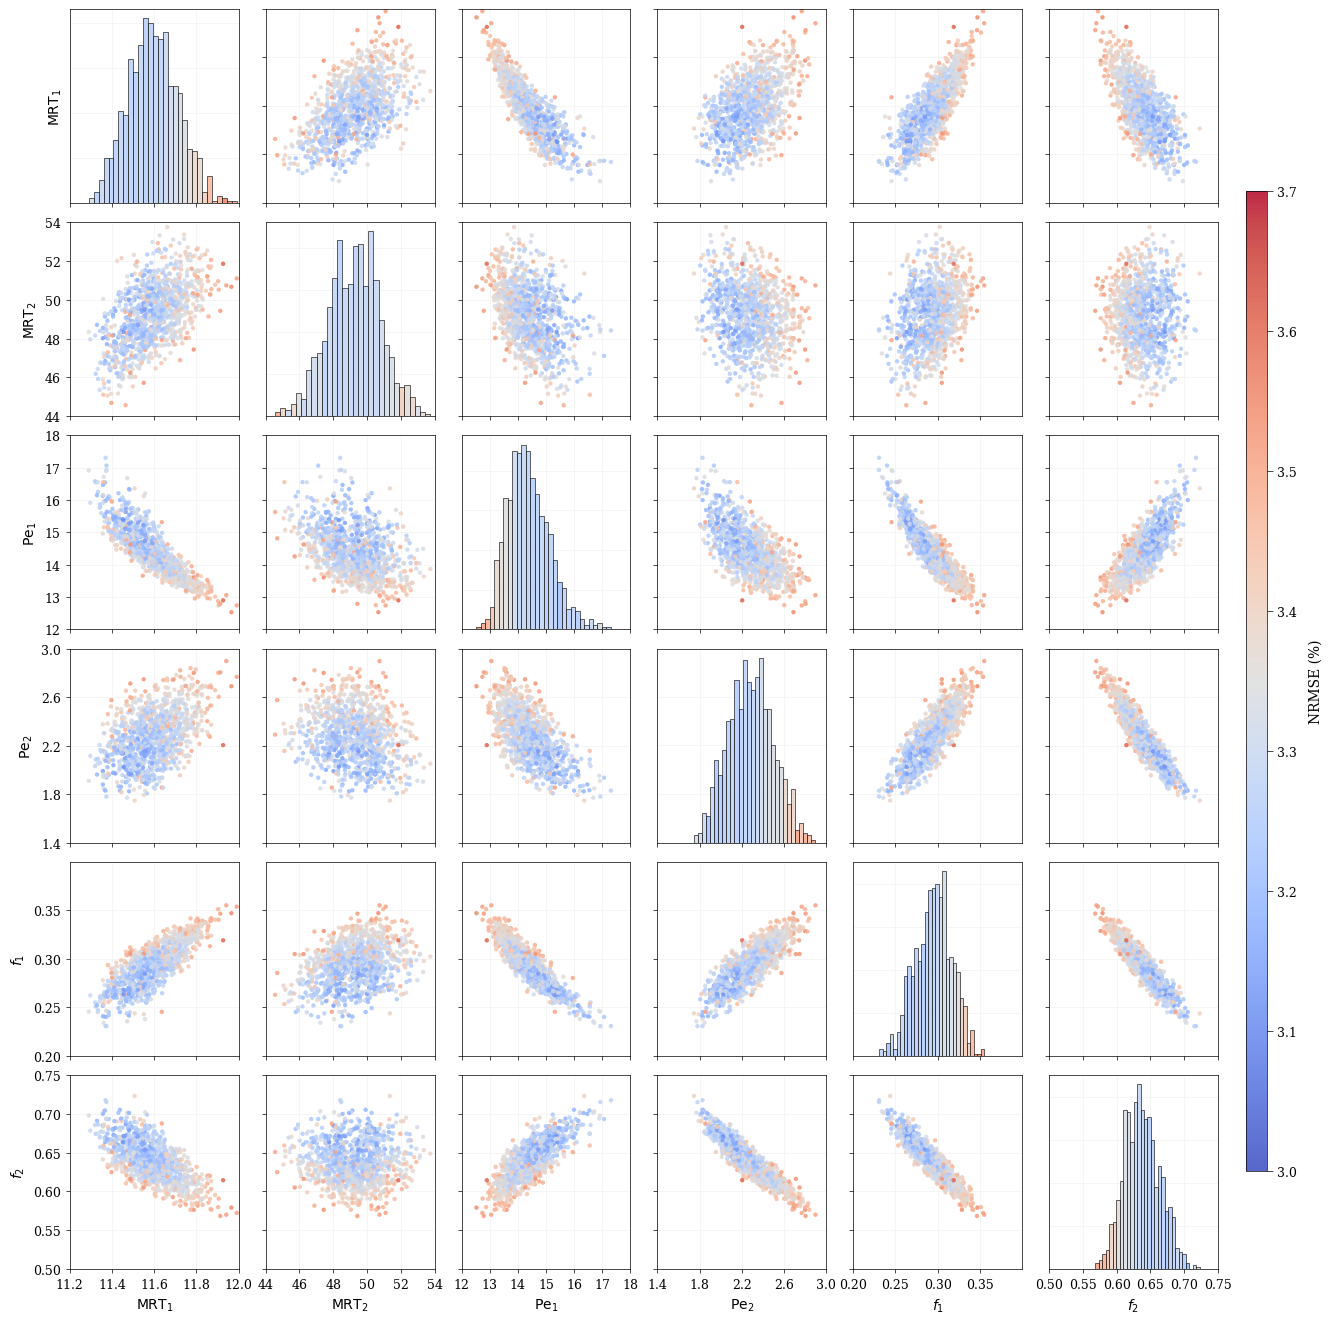

In [77]:
params = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]
labels = {
    "best_MRT1": r"$\mathrm{MRT}_1$",
    "best_MRT2": r"$\mathrm{MRT}_2$",
    "best_Pe1": r"$\mathrm{Pe}_1$",
    "best_Pe2": r"$\mathrm{Pe}_2$",
    "best_fr1": r"$f_1$",
    "best_fr2": r"$f_2$",
}

# Change this to control colormap (e.g., "jet", "viridis", "plasma")
cmap_name = "coolwarm"
cmap = plt.get_cmap(cmap_name)

tick_map = {
    "best_MRT1": [11.2, 11.4, 11.6, 11.8, 12.0],
    "best_MRT2": [44, 46, 48, 50, 52, 54],
    "best_Pe1": [12, 13, 14, 15, 16, 17, 18],
    "best_Pe2": [1.4, 1.8, 2.2, 2.6, 3.0],
    "best_fr1": [0.20, 0.25, 0.30, 0.35],
    "best_fr2": [0.50, 0.55, 0.60, 0.65, 0.70, 0.75],
}

limit_map = {
    "best_MRT1": [11.2, 12.0],
    "best_MRT2": [44, 54],
    "best_Pe1": [12, 18],
    "best_Pe2": [1.4, 3.0],
    "best_fr1": [0.2, 0.4],
    "best_fr2": [0.5, 0.75],
}

n = len(params)
fig, axes = plt.subplots(n, n, figsize=(14, 14), facecolor="white")

for i, py in enumerate(params):
    for j, px in enumerate(params):
        ax = axes[i, j]
        ax.set_facecolor("white")
        ax.set_axisbelow(True)
        ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

        if i == j:
            values = ensemble[px].to_numpy()
            j_vals = ensemble["J_m"].to_numpy()

            counts, edges = np.histogram(values, bins=30)
            bin_ids = np.digitize(values, edges) - 1
            bin_ids = np.clip(bin_ids, 0, len(edges) - 2)

            bin_medians = np.full(len(edges) - 1, np.nan)
            for k in range(len(bin_medians)):
                mask = bin_ids == k
                if np.any(mask):
                    bin_medians[k] = np.median(j_vals[mask])

            nrmse_pct = bin_medians * 100.0
            bin_colors = [
                cmap(nrmse_norm(v)) if not np.isnan(v) else (0.85, 0.85, 0.85, 1.0)
                for v in nrmse_pct
            ]

            ax.bar(
                edges[:-1],
                counts,
                width=np.diff(edges),
                align="edge",
                color=bin_colors,
                edgecolor="black",
                linewidth=_pt_hair,
                alpha=0.85,
            )
        else:
            sc = ax.scatter(
                ensemble[px],
                ensemble[py],
                c=ensemble["NRMSE_pct"],
                cmap=cmap,
                norm=nrmse_norm,
                s=10,
                alpha=0.85,
                edgecolors="none",
            )

        for side in ax.spines:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(_pt_hair)
            ax.spines[side].set_color("black")

        ax.set_xticks(tick_map[px])
        if i != j:
            ax.set_yticks(tick_map[py])

        if px in ["best_fr1", "best_fr2"]:
            ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
        elif px in ["best_MRT1", "best_Pe2"]:
            ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f"))

        if i != j and py in ["best_fr1", "best_fr2"]:
            ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))
        elif i != j and py in ["best_MRT1", "best_Pe2"]:
            ax.yaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.1f"))

        if i == j:
            ax.tick_params(axis="y", left=False, labelleft=False)

        ax.set_xlim(limit_map[px])
        if i != j:
            ax.set_ylim(limit_map[py])

        ax.tick_params(
            axis="both", 
            which="major",
            direction="out",
            length=3,
            width=_pt_hair,
            colors="black",
            top=False,
            right=False,
            labelsize=9,
        )

        if i == n - 1:
            ax.set_xlabel(labels[px], fontsize=10)
        else:
            ax.set_xlabel("")
            ax.tick_params(axis="x", labelbottom=False)

        if j == 0:
            ax.set_ylabel(labels[py], fontsize=10)
        else:
            ax.set_ylabel("")
            ax.tick_params(axis="y", labelleft=False)

fig.subplots_adjust(left=0.08, bottom=0.08, right=0.90, top=0.98, wspace=0.16, hspace=0.10)
cax = fig.add_axes([0.92, 0.15, 0.015, 0.70])
cbar = fig.colorbar(sc, cax=cax)
cbar.set_label("NRMSE (%)", labelpad=8, fontsize=10)
cbar.ax.tick_params(width=_pt_hair, length=4, labelsize=9)
cbar.outline.set_linewidth(_pt_hair)

fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

fig.savefig(
    "pairwise_scatter_hist_nrmse.pdf",
    facecolor="white",
    edgecolor="none",
    bbox_inches="tight",
    pad_inches=0.25,
)

plt.show()

## Cluster-colored scatter plots (from clustering evaluation)


## NRMSE vs each parameter

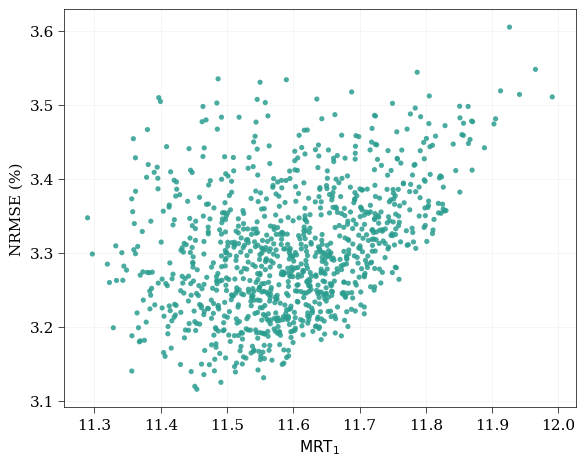

In [58]:
x = "best_MRT1"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$\mathrm{MRT}_1$")
ax.set_ylabel("NRMSE (%)")

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

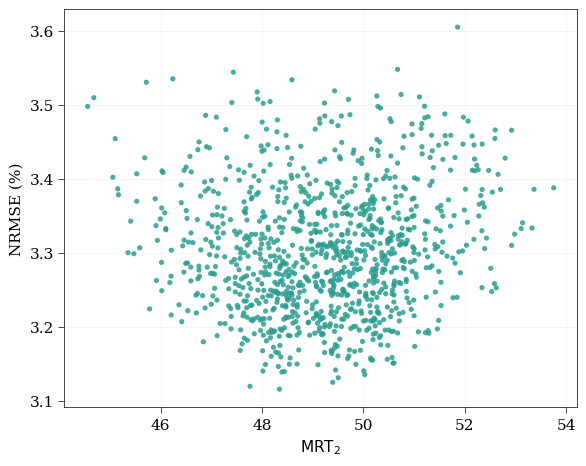

In [59]:
x = "best_MRT2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$\mathrm{MRT}_2$")
ax.set_ylabel("NRMSE (%)")

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

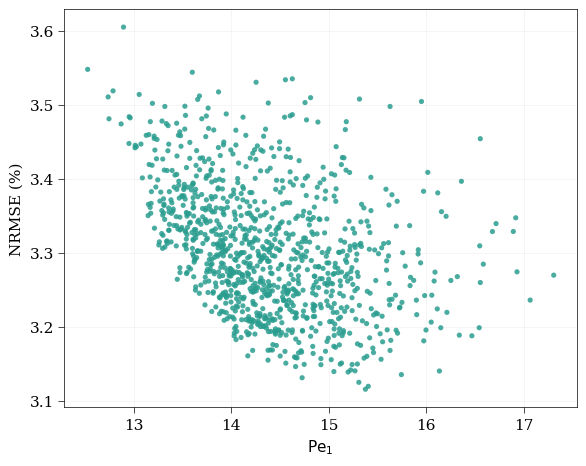

In [60]:
x = "best_Pe1"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$\mathrm{Pe}_1$")
ax.set_ylabel("NRMSE (%)")

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

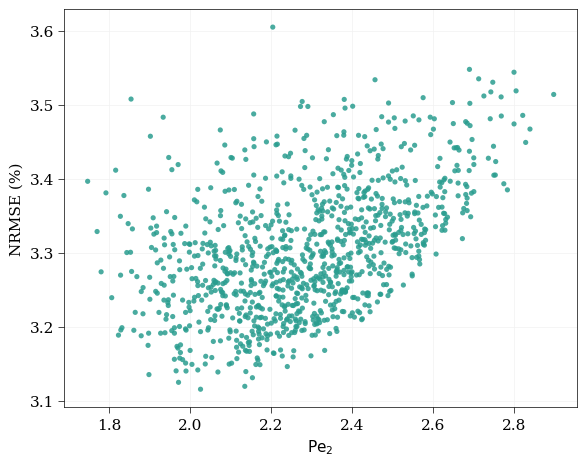

In [61]:
x = "best_Pe2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$\mathrm{Pe}_2$")
ax.set_ylabel("NRMSE (%)")

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

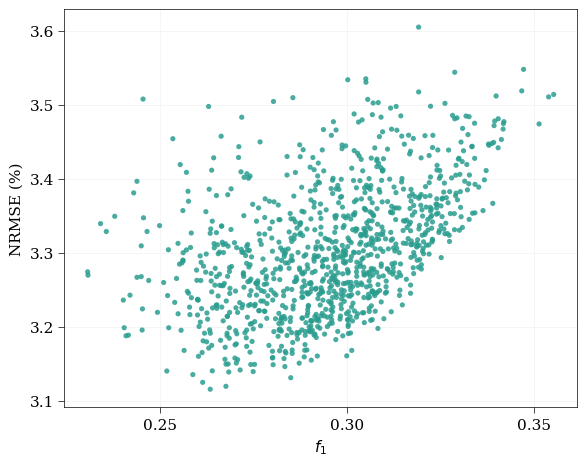

In [62]:
x = "best_fr1"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$f_1$")
ax.set_ylabel("NRMSE (%)")
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

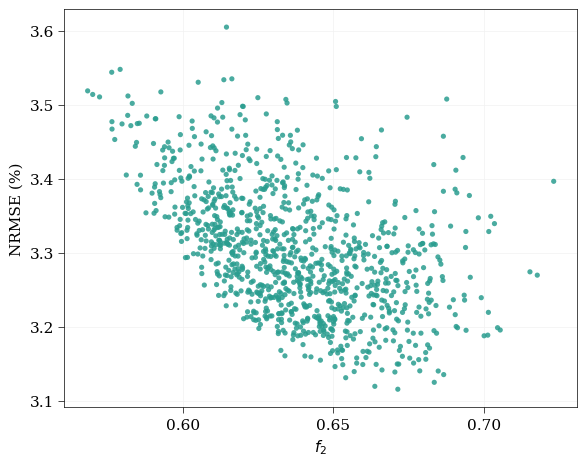

In [63]:
x = "best_fr2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    ensemble[x],
    ensemble["NRMSE_pct"],
    s=14,
    alpha=0.85,
    color="#2a9d8f",
    edgecolors="none",
)

ax.set_xlabel(r"$f_2$")
ax.set_ylabel("NRMSE (%)")
ax.xaxis.set_major_locator(mpl.ticker.MultipleLocator(0.05))
ax.xaxis.set_major_formatter(mpl.ticker.FormatStrFormatter("%.2f"))

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

plt.show()

In [42]:
cluster_csv = repo_root / 'two_components/outputs/clustering_evaluation/best_clustering_assignments.csv'
if not cluster_csv.exists():
    cluster_csv = repo_root / 'two_components_/outputs/clustering_evaluation/best_clustering_assignments.csv'

cluster_df = pd.read_csv(cluster_csv)
cluster_codes, _ = pd.factorize(cluster_df['cluster_id'])
cluster_df[['best_MRT1','best_MRT2','best_Pe1','best_Pe2','best_fr1','best_fr2','cluster_id']].head()


,best_MRT1,best_MRT2,best_Pe1,best_Pe2,best_fr1,best_fr2,cluster_id
0,11.499208,48.875504,14.306458,2.316610,0.295805,0.631880,23
1,11.594517,48.033103,14.372158,2.499534,0.309429,0.603831,10
2,11.543427,46.876277,14.969934,2.432204,0.290120,0.624254,6
3,11.578372,48.419834,14.336083,2.477860,0.303948,0.625736,23
4,11.693850,48.764312,13.486999,2.749373,0.333392,0.584234,18


## MRT1 vs MRT2 (cluster_id colored)


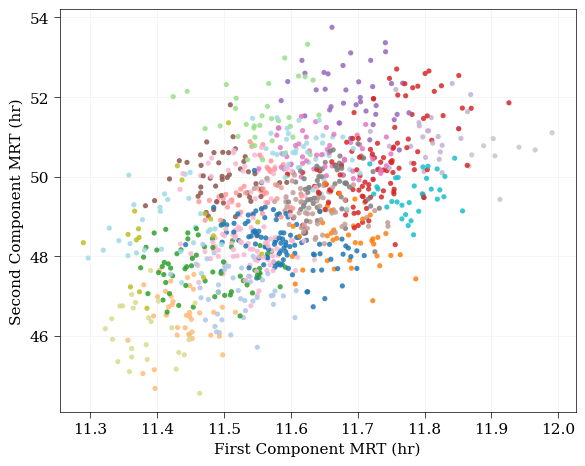

In [43]:
cx = "best_MRT1"
cy = "best_MRT2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    cluster_df[cx],
    cluster_df[cy],
    c=cluster_codes,
    cmap="tab20",
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component MRT (hr)")
ax.set_ylabel("Second Component MRT (hr)")

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_clusters_mrt1_mrt2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()


## Pe1 vs Pe2 (cluster_id colored)


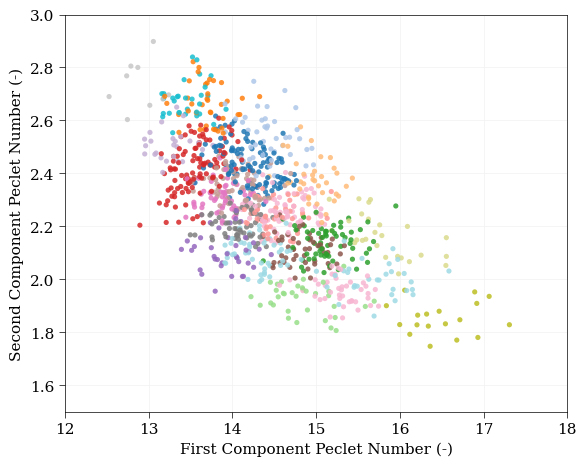

In [44]:
cx = "best_Pe1"
cy = "best_Pe2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    cluster_df[cx],
    cluster_df[cy],
    c=cluster_codes,
    cmap="tab20",
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component Peclet Number (-)")
ax.set_ylabel("Second Component Peclet Number (-)")
ax.set_xlim([12, 18])
ax.set_ylim([1.5, 3])

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_clusters_pe1_pe2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()


## fr1 vs fr2 (cluster_id colored)


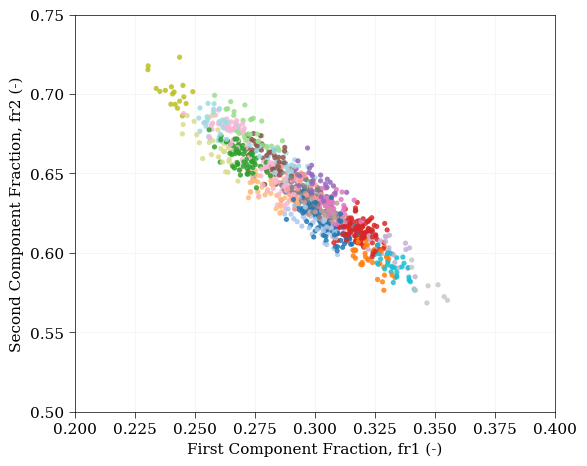

In [45]:
cx = "best_fr1"
cy = "best_fr2"

fig, ax = plt.subplots(figsize=(6.0, 4.8), facecolor="white")
ax.set_facecolor("white")
ax.set_axisbelow(True)
ax.grid(True, which="major", linewidth=_pt_hair, color=_grid_gray, linestyle="-")

ax.scatter(
    cluster_df[cx],
    cluster_df[cy],
    c=cluster_codes,
    cmap="tab20",
    s=14,
    alpha=0.85,
    edgecolors="none",
)

ax.set_xlabel("First Component Fraction, fr1 (-)")
ax.set_ylabel("Second Component Fraction, fr2 (-)")
ax.set_xlim([0.2, 0.4])
ax.set_ylim([0.5, 0.75])

for side in ax.spines:
    ax.spines[side].set_visible(True)
    ax.spines[side].set_linewidth(_pt_hair)
    ax.spines[side].set_color("black")

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    length=4,
    width=_pt_hair,
    colors="black",
    top=False,
    right=False,
)

fig.tight_layout()
fig.patch.set_linewidth(0)
fig.patch.set_edgecolor("none")

# Uncomment to save as PDF
# fig.savefig(
#     "scatter_clusters_fr1_fr2.pdf",
#     facecolor="white",
#     edgecolor="none",
#     bbox_inches="tight",
#     pad_inches=0.25,
# )

plt.show()


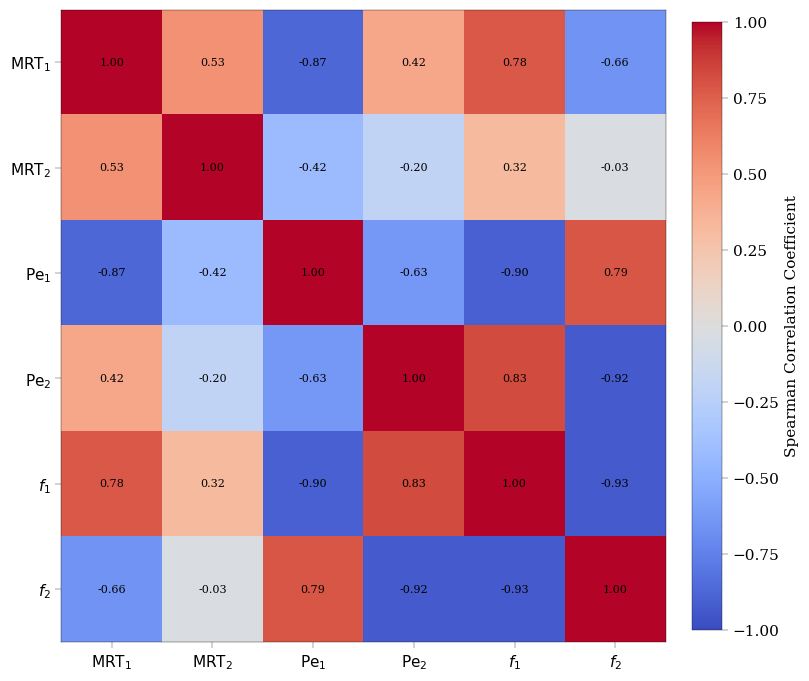

In [81]:
# Spearman correlation heatmap (parameters only) with journal-style formatting
param_cols_corr = ["best_MRT1", "best_MRT2", "best_Pe1", "best_Pe2", "best_fr1", "best_fr2"]

corr_cols = param_cols_corr
corr_df = ensemble[corr_cols].corr(method="spearman")

pretty_labels = [
    r"$\mathrm{MRT}_1$",
    r"$\mathrm{MRT}_2$",
    r"$\mathrm{Pe}_1$",
    r"$\mathrm{Pe}_2$",
    r"$f_1$",
    r"$f_2$",
]

_pt = 1.0
_pt_hair = 0.25
font_size = 11

with plt.rc_context(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
        "font.size": font_size,
        "axes.labelsize": font_size,
        "xtick.labelsize": font_size,
        "ytick.labelsize": font_size,
        "legend.fontsize": font_size,
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.edgecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "xtick.direction": "out",
        "ytick.direction": "out",
        "pdf.fonttype": 42,
    }
):
    fig, ax = plt.subplots(figsize=(8.2, 7), facecolor="white")
    ax.set_facecolor("white")

    im = ax.imshow(corr_df.to_numpy(), cmap="coolwarm", vmin=-1, vmax=1, aspect="auto")

    ax.set_xticks(np.arange(len(corr_cols)))
    ax.set_yticks(np.arange(len(corr_cols)))
    ax.set_xticklabels(pretty_labels, rotation=0, ha="center")
    ax.set_yticklabels(pretty_labels)

    for i in range(len(corr_cols)):
        for j in range(len(corr_cols)):
            ax.text(j, i, f"{corr_df.iloc[i, j]:.2f}", ha="center", va="center", color="black", fontsize=8)

    for side in ax.spines:
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(_pt_hair)
        ax.spines[side].set_color("black")

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        length=4,
        width=_pt_hair,
        colors="black",
        top=False,
        right=False,
    )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Spearman Correlation Coefficient")
    cbar.ax.tick_params(width=_pt_hair, length=4)
    cbar.outline.set_linewidth(_pt_hair)

    fig.tight_layout()
    fig.patch.set_linewidth(0)
    fig.patch.set_edgecolor("none")

    fig.savefig(
        "spearman_parameters_nrmse.pdf",
        facecolor="white",
        edgecolor="none",
        bbox_inches="tight",
        pad_inches=0.25,
    )

    plt.show()